# 🕸️ Dia 2 — Web Scraping: Introdução
**Data:** 28/05/2026 | **Horário:** 19h – 22h

---

## O que vamos aprender hoje?

1. O que é Web Scraping e para que serve
2. Como funciona a web (HTML básico)
3. Biblioteca `requests` — buscando páginas
4. Biblioteca `BeautifulSoup` — extraindo dados do HTML
5. Prática: scraping de um site real


---
## 🕐 PARTE 1 — O que é Web Scraping? (19h – 19h30)

### Web Scraping = "Raspar" dados da web

É uma técnica para **coletar dados de sites automaticamente** usando código Python.

### Quando usar Web Scraping?
- Quando os dados que você precisa **estão em um site**, mas não há CSV para baixar
- Para coletar preços de produtos, notícias, dados de clima, etc.
- Para automatizar coleta de dados que muda frequentemente

### Exemplos de uso real:
| Empresa/Uso | O que coleta |
|------------|-------------|
| Buscadores de preço | Preços de produtos em e-commerces |
| Empresas de RH | Vagas de emprego em múltiplos sites |
| Pesquisadores | Notícias, artigos, comentários |
| Governo | Monitoramento de preços de alimentos |

### ⚠️ Cuidados importantes:
- Verifique sempre o **robots.txt** do site
- Não sobrecarregue servidores (use pausas entre requisições)
- Respeite os **Termos de Uso** do site
- Para aprender, use **sites criados para praticar scraping!**

### Sites para praticar (100% liberados):
- **books.toscrape.com** — livraria fictícia
- **quotes.toscrape.com** — citações famosas
- **toscrape.com** — vários exercícios


---
## 🕐 PARTE 2 — Como funciona a web (HTML básico) (19h30 – 20h)

### HTML = HyperText Markup Language

Todo site é feito de HTML. É como o "esqueleto" da página. O Python precisa entender essa estrutura para extrair dados.

### Estrutura básica de HTML:
```html
<html>
  <body>
    <h1>Título da página</h1>
    <p>Um parágrafo de texto</p>
    <a href="https://site.com">Um link</a>
    <table>
      <tr>
        <td>Célula 1</td>
        <td>Célula 2</td>
      </tr>
    </table>
  </body>
</html>
```

### Tags HTML mais importantes para scraping:
| Tag | O que é |
|-----|--------|
| `<h1>`, `<h2>` | Títulos |
| `<p>` | Parágrafos |
| `<a href='...'>` | Links |
| `<table>` | Tabelas |
| `<div>` | Divisões/seções |
| `<span>` | Texto inline |
| `class='...'` | Classe CSS (ajuda a identificar elementos) |
| `id='...'` | Identificador único |

### Como inspecionar um site:
1. Abra o site no navegador
2. Clique com botão direito → **Inspecionar** (ou F12)
3. Veja o HTML de qualquer elemento

---
## 🕑 PARTE 3 — Biblioteca requests (20h – 20h30)

### O que é requests?

A biblioteca `requests` permite que o Python **faça pedidos (requests) a servidores web** — como se fosse um navegador, mas sem interface gráfica.

In [11]:
# Verificar se as bibliotecas estão instaladas
# Se não estiver, execute: pip install requests beautifulsoup4

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import time

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [12]:
# Fazer uma requisição simples
# Vamos acessar o site de prática: books.toscrape.com

url = 'http://books.toscrape.com/'

# GET = buscar a página
resposta = requests.get(url)

# Verificar se deu certo
print(f'Status da resposta: {resposta.status_code}')
print()
print('Códigos de status HTTP:')
print('  200 = OK (sucesso!)')
print('  404 = Página não encontrada')
print('  403 = Acesso proibido')
print('  500 = Erro no servidor')

Status da resposta: 200

Códigos de status HTTP:
  200 = OK (sucesso!)
  404 = Página não encontrada
  403 = Acesso proibido
  500 = Erro no servidor


In [13]:
# Ver o conteúdo HTML da página (primeiros 500 caracteres)
print('Primeiros 500 caracteres do HTML:')
print(resposta.text[:500])

Primeiros 500 caracteres do HTML:
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


In [14]:
# Verificar se a requisição foi bem-sucedida antes de continuar
if resposta.status_code == 200:
    print('✅ Página acessada com sucesso!')
else:
    print(f'❌ Erro: status {resposta.status_code}')

✅ Página acessada com sucesso!


---
## 🕑 PARTE 4 — BeautifulSoup: extraindo dados do HTML (20h30 – 21h30)

### O que é BeautifulSoup?

O `BeautifulSoup` é uma biblioteca que **"analisa" o HTML** e permite navegar pela estrutura como se fosse uma árvore.

### Metáfora:
- `requests` = o carteiro que **busca** a carta (HTML)
- `BeautifulSoup` = você **lendo e separando** o conteúdo da carta

In [15]:
# Criar o objeto BeautifulSoup
# 'html.parser' é o analisador padrão do Python

soup = BeautifulSoup(resposta.text, 'html.parser')

# Ver o HTML formatado (primeiras linhas)
print(soup.prettify()[:800])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js" lang="en-us">
 <!--<![endif]-->
 <head>
  <title>
   All products | Books to Scrape - Sandbox
  </title>
  <meta content="text/html; charset=utf-8" http-equiv="content-type"/>
  <meta content="24th Jun 2016 09:29" name="created"/>
  <meta content="" name="description"/>
  <meta content="width=device-width" name="viewport"/>
  <meta content="NOARCHIVE,NOCACHE" name="robots"/>
  <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
  <!--[if lt IE 9]>
        <script src="//html5sh


In [16]:
# Buscar o título da página
titulo = soup.find('title')
print('Título da página:')
print(titulo.text)

Título da página:

    All products | Books to Scrape - Sandbox



In [17]:

# Buscar TODOS os livros na página
# Cada livro está dentro de uma tag <article class='product_pod'>

livros = soup.find_all('article', class_='product_pod')

print(f'Quantidade de livros encontrados: {len(livros)}')
print()

# Ver o HTML do primeiro livro para entender a estrutura
print('Estrutura HTML do primeiro livro:')
print(livros[0].prettify()[:250])


Quantidade de livros encontrados: 20

Estrutura HTML do primeiro livro:
<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div


In [19]:

# Extrair o TÍTULO do primeiro livro — passo a passo

primeiro_livro = livros[0]

# Passo 1: encontrar a tag <h3>
tag_h3 = primeiro_livro.find('h3')

# Passo 2: dentro da <h3>, encontrar o link <a>
tag_link = tag_h3.find('a')

# Passo 3: pegar o atributo 'title' desse link
titulo_livro = tag_link['title']

print(f'Título: {titulo_livro}')


Título: A Light in the Attic


In [20]:

# Extrair o PREÇO do primeiro livro

# O preço está na tag <p class='price_color'>
preco_texto = primeiro_livro.find('p', class_='price_color').text
print(f'Texto bruto: {preco_texto}')

# O texto vem com o símbolo £ — precisamos remover para virar número
preco = float(preco_texto.replace('Â', '').replace('£', '').strip())
print(f'Preço como número: {preco}')


Texto bruto: Â£51.77
Preço como número: 51.77


In [21]:

# Extrair a AVALIAÇÃO do primeiro livro

# A avaliação fica guardada como classe CSS: <p class="star-rating Three">
tag_avaliacao = primeiro_livro.find('p', class_='star-rating')

# .['class'] retorna uma lista com todas as classes da tag
# Ex: ['star-rating', 'Three']
classes = tag_avaliacao['class']
print(f'Classes encontradas: {classes}')

# O segundo item da lista (índice 1) é a avaliação em inglês
avaliacao_raw = classes[1]
print(f'Avaliação em inglês: {avaliacao_raw}')

# Dicionário para converter inglês → número
estrelas = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
avaliacao_num = estrelas[avaliacao_raw]
print(f'Avaliação em número: {avaliacao_num} estrelas')


Classes encontradas: ['star-rating', 'Three']
Avaliação em inglês: Three
Avaliação em número: 3 estrelas


In [22]:

# Agora vamos extrair TODOS os livros da página em um loop!

lista_livros = []
estrelas = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}

for livro in livros:
    # Título
    tag_h3   = livro.find('h3')
    tag_link = tag_h3.find('a')
    titulo   = tag_link['title']

    # Preço
    preco_texto = livro.find('p', class_='price_color').text
    preco = float(preco_texto.replace('Â', '').replace('£', '').strip())

    # Avaliação
    classes   = livro.find('p', class_='star-rating')['class']
    avaliacao = estrelas[classes[1]]

    lista_livros.append({
        'titulo':    titulo,
        'preco':     preco,
        'avaliacao': avaliacao
    })

print(f'Total de livros coletados: {len(lista_livros)}')
print(lista_livros[:3])


Total de livros coletados: 20
[{'titulo': 'A Light in the Attic', 'preco': 51.77, 'avaliacao': 3}, {'titulo': 'Tipping the Velvet', 'preco': 53.74, 'avaliacao': 1}, {'titulo': 'Soumission', 'preco': 50.1, 'avaliacao': 1}]


In [23]:
# Converter para DataFrame!
df_livros = pd.DataFrame(lista_livros)
print('DataFrame criado:')
df_livros.head(10)

DataFrame criado:


,titulo,preco,avaliacao
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5
5,The Requiem Red,22.65,1
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4
7,The Coming Woman: A Novel Based on the Life of...,17.93,3
8,The Boys in the Boat: Nine Americans and Their...,22.60,4
9,The Black Maria,52.15,1


In [24]:
# Estatísticas dos livros
print('Estatísticas dos preços:')
print(df_livros['preco'].describe())

Estatísticas dos preços:
count    20.000000
mean     38.048500
std      15.135231
min      13.990000
25%      22.637500
50%      41.380000
75%      51.865000
max      57.250000
Name: preco, dtype: float64


Livros por avaliação:
avaliacao
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


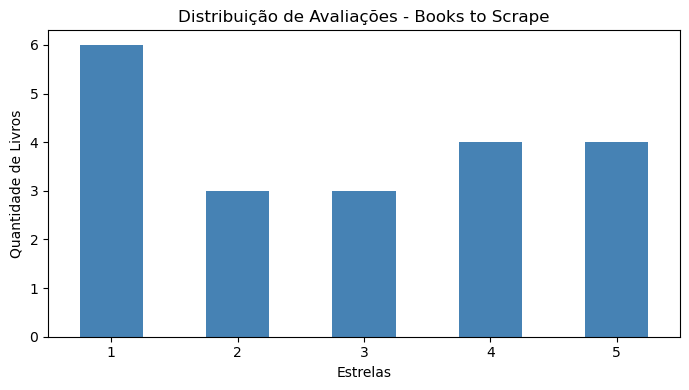

In [25]:
# Distribuição por avaliação
print('Livros por avaliação:')
print(df_livros['avaliacao'].value_counts().sort_index())

plt.figure(figsize=(7, 4))
df_livros['avaliacao'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xlabel('Estrelas')
plt.ylabel('Quantidade de Livros')
plt.title('Distribuição de Avaliações - Books to Scrape')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# Livros mais baratos
print('5 livros mais baratos:')
df_livros.sort_values('preco').head(5)

5 livros mais baratos:


,titulo,preco,avaliacao
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,2
12,Set Me Free,17.46,5
7,The Coming Woman: A Novel Based on the Life of...,17.93,3
11,Shakespeare's Sonnets,20.66,4
8,The Boys in the Boat: Nine Americans and Their...,22.60,4


---
## 🕒 PARTE 5 — Scraping de Múltiplas Páginas (21h30 – 22h)

O site tem **50 páginas** de livros. Vamos coletar as primeiras 3 páginas!


### Como coletar várias páginas?

O site tem 50 páginas. A URL muda assim:
- Página 1: `http://books.toscrape.com/`
- Página 2: `http://books.toscrape.com/catalogue/page-2.html`
- Página 3: `http://books.toscrape.com/catalogue/page-3.html`

Vamos usar um `for` para percorrer as páginas e guardar tudo em uma lista!


In [27]:

# Coletar 3 páginas de livros

todos_livros = []
estrelas = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}

for pagina in range(1, 4):  # 1, 2, 3

    # Página 1 tem URL diferente das demais
    if pagina == 1:
        url_pagina = 'http://books.toscrape.com/'
    else:
        url_pagina = f'http://books.toscrape.com/catalogue/page-{pagina}.html'

    # Buscar a página
    resp      = requests.get(url_pagina)
    soup_pag  = BeautifulSoup(resp.text, 'html.parser')
    livros_pag = soup_pag.find_all('article', class_='product_pod')

    # Coletar os dados de cada livro
    for livro in livros_pag:
        tag_h3   = livro.find('h3')
        tag_link = tag_h3.find('a')
        titulo   = tag_link['title']

        preco_texto = livro.find('p', class_='price_color').text
        preco = float(preco_texto.replace('Â', '').replace('£', '').strip())

        classes   = livro.find('p', class_='star-rating')['class']
        avaliacao = estrelas[classes[1]]

        todos_livros.append({'titulo': titulo, 'preco': preco, 'avaliacao': avaliacao})

    print(f'Página {pagina}: {len(livros_pag)} livros coletados')
    time.sleep(1)  # boa prática: esperar entre requisições

print(f'\nTotal geral: {len(todos_livros)} livros')


Página 1: 20 livros coletados
Página 2: 20 livros coletados
Página 3: 20 livros coletados

Total geral: 60 livros


In [28]:
# Converter para DataFrame e analisar
df_todos = pd.DataFrame(todos_livros)

print('Resumo:')
print(f'Total de livros: {len(df_todos)}')
print(f'Preço médio: £{df_todos["preco"].mean():.2f}')
print(f'Preço mínimo: £{df_todos["preco"].min():.2f}')
print(f'Preço máximo: £{df_todos["preco"].max():.2f}')

df_todos.head()

Resumo:
Total de livros: 60
Preço médio: £35.00
Preço mínimo: £12.84
Preço máximo: £57.31


,titulo,preco,avaliacao
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


In [29]:
# Salvar os dados coletados
df_todos.to_csv('./dados/livros_scraped.csv', index=False)
print('Dados salvos em: ./dados/livros_scraped.csv')

Dados salvos em: ./dados/livros_scraped.csv



---
## ✏️ Exercícios

**Exercício 1:** Usando `df_todos`, mostre os 5 livros **mais caros** (use `.sort_values()` e `.tail()`).

**Exercício 2:** Acesse `quotes.toscrape.com` e use `soup.find_all('div', class_='quote')` para mostrar quantas citações existem na primeira página.

**Exercício 3:** Crie um gráfico de barras mostrando **quantos livros** existem para cada avaliação (1 a 5 estrelas).


In [ ]:
# Exercício 3 — Resolução
plt.figure(figsize=(8, 5))
plt.scatter(df_todos['avaliacao'], df_todos['preco'], alpha=0.5, color='steelblue')
plt.xlabel('Avaliação (estrelas)')
plt.ylabel('Preço (£)')
plt.title('Preço vs. Avaliação dos Livros')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

---
## 📋 Resumo do Dia 2

Hoje aprendemos:
- ✅ O que é **Web Scraping** e quando usar
- ✅ Estrutura básica de **HTML**
- ✅ Biblioteca **requests** para buscar páginas
- ✅ Biblioteca **BeautifulSoup** para extrair dados
- ✅ `find()` e `find_all()` para navegar no HTML
- ✅ Scraping de **múltiplas páginas** com loop

## 🔜 Próxima aula (29/05)
**Web Scraping de Tabelas + Projeto Final** — pandas.read_html, Wikipedia e mini projeto integrando tudo!